# 01 · Message passing on the hierarchical rhythm graph

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/01_message_passing.ipynb)

Every model in this repository — from the plain GAT baseline to the full
Kuramoto-attention Neural ODE — is built on the same primitive: **message
passing**, where each node updates its state from its graph neighbors'
states. This notebook makes that primitive concrete on the project's real
graph: 14 EEG electrodes (outer level), each containing 5 rhythm nodes —
delta, theta, alpha, beta, gamma (inner level) — connected by
*same-band spatial* edges (same rhythm, neighboring electrodes) and
*cross-frequency local* edges (different rhythms, same electrode).

No trained model is needed to see the key idea: **information can only
reach a node through the edges that touch it, one hop at a time.** Later
notebooks replace the plain averaging used here with learned attention
(02), diffusion (03), phase synchronization (04), and finally a continuous
version of all of it integrated by an ODE solver (05, 06).

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


In [2]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph, SPATIAL_SAME_BAND, CROSS_FREQUENCY_LOCAL
from hmb_kuramoto_ode.contracts import BANDS

REGIONS = 4  # a small number of electrodes keeps the plots legible; the real STEW graph uses 14
edge_index, edge_types = build_hierarchical_graph(REGIONS)
num_nodes = REGIONS * 5

print(f"{num_nodes} nodes ({REGIONS} electrodes x 5 rhythms: {', '.join(BANDS)})")
print(f"{edge_index.shape[1]} directed edges")
print(f"  same-band spatial edges:     {(edge_types == SPATIAL_SAME_BAND).sum().item()}")
print(f"  cross-frequency local edges: {(edge_types == CROSS_FREQUENCY_LOCAL).sum().item()}")


20 nodes (4 electrodes x 5 rhythms: delta, theta, alpha, beta, gamma)
110 directed edges
  same-band spatial edges:     30
  cross-frequency local edges: 80


## 1. Visualizing the graph

Each column below is one electrode; each row is one rhythm. Blue edges connect
the *same* rhythm across neighboring electrodes; orange edges connect
*different* rhythms within one electrode.

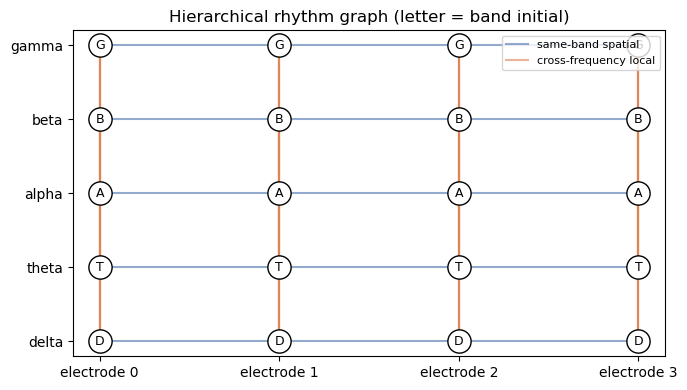

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
positions = {n: (n // 5, n % 5) for n in range(num_nodes)}
src, dst = edge_index
colors = {int(SPATIAL_SAME_BAND): "#4C72B0", int(CROSS_FREQUENCY_LOCAL): "#DD8452"}
seen = set()
for s, d, t in zip(src.tolist(), dst.tolist(), edge_types.tolist()):
    if (d, s) in seen:  # each undirected pair is stored as two directed edges
        continue
    seen.add((s, d))
    (x0, y0), (x1, y1) = positions[s], positions[d]
    label = "same-band spatial" if t == SPATIAL_SAME_BAND else "cross-frequency local"
    already = label in ax.get_legend_handles_labels()[1]
    ax.plot([x0, x1], [y0, y1], color=colors[t], alpha=0.6, zorder=1, label=None if already else label)
for n, (x, y) in positions.items():
    ax.scatter(x, y, s=280, color="white", edgecolor="black", zorder=2)
    ax.text(x, y, BANDS[y][0].upper(), ha="center", va="center", fontsize=9, zorder=3)
ax.set_xticks(range(REGIONS)); ax.set_xticklabels([f"electrode {i}" for i in range(REGIONS)])
ax.set_yticks(range(5)); ax.set_yticklabels(BANDS)
ax.set_title("Hierarchical rhythm graph (letter = band initial)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## 2. One step of message passing

The simplest possible aggregation: a node's new state is the **mean of its
incoming neighbors' states**. No learned weights yet — this is the primitive
that `EdgeAttention` (notebook 02) and the ODE vector field (notebooks 03-06)
replace with something learned.

In [4]:
def mean_aggregate(h, edge_index, num_nodes):
    src, dst = edge_index
    out = torch.zeros_like(h)
    out.index_add_(0, dst, h[src])
    degree = torch.zeros(num_nodes, dtype=h.dtype).index_add_(0, dst, torch.ones_like(dst, dtype=h.dtype))
    return out / degree.clamp(min=1)[:, None]


## 3. Watching a signal spread

Place a unit impulse on a single node (electrode 0, delta band) and apply
`mean_aggregate` repeatedly. Because the graph only has direct edges to
same-band neighbors and same-electrode rhythms, the signal needs multiple
hops to reach a node that is both spatially and spectrally far away —
exactly the "receptive field grows by depth" limitation that motivates
continuous, always-on coupling in the full model.

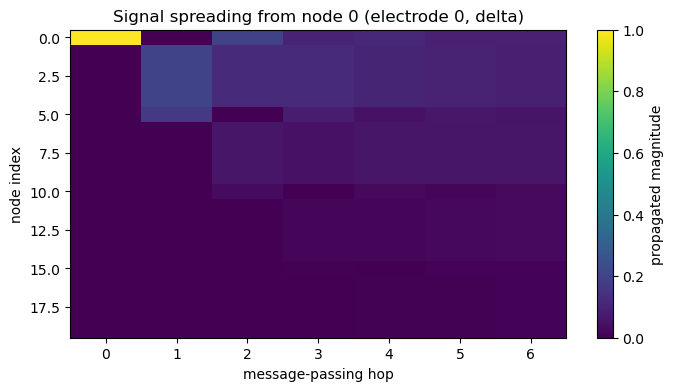

magnitude at the farthest node (19) per hop:
  hop 0: 0.0000
  hop 1: 0.0000
  hop 2: 0.0000
  hop 3: 0.0000
  hop 4: 0.0041
  hop 5: 0.0056
  hop 6: 0.0095


In [5]:
seed_everything(7)
signal = torch.zeros(num_nodes, 1)
source_node = 0  # electrode 0, delta band
signal[source_node] = 1.0

HOPS = 6
history = [signal.squeeze(1).clone()]
h = signal
for _ in range(HOPS):
    h = mean_aggregate(h, edge_index, num_nodes)
    history.append(h.squeeze(1).clone())
history = torch.stack(history)  # [hops+1, num_nodes]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(history.T, aspect="auto", cmap="viridis")
ax.set_xlabel("message-passing hop"); ax.set_ylabel("node index")
ax.set_title(f"Signal spreading from node {source_node} (electrode 0, delta)")
fig.colorbar(im, ax=ax, label="propagated magnitude")
plt.show()

far_node = num_nodes - 1  # last electrode, gamma band: spatially and spectrally farthest
print(f"magnitude at the farthest node ({far_node}) per hop:")
for hop, value in enumerate(history[:, far_node].tolist()):
    print(f"  hop {hop}: {value:.4f}")


## Key takeaway

Plain message passing only mixes information along explicit edges, one hop
per layer/step. The rest of this repository keeps that graph structure but
changes *how* neighbors are weighted (attention, notebook 02), *what* gets
mixed (diffusion vs. phase-only coupling, notebooks 03-04), and *how long*
mixing runs — a fixed number of layers vs. a continuously integrated ODE
(notebooks 05-06).